# 05c - Task 3: Hyperparameter tuning (LogReg ElasticNet)

Parallel variant of 05_tuning.ipynb / 05b_logreg_ridge_tuning.ipynb's search - same
pipeline, applied to LogReg ElasticNet.

04_models.ipynb's baseline used a fixed `l1_ratio=0.5` (an arbitrary blend point never
itself tuned) and scored 0.7196, below Ridge's 0.7246. This tunes `l1_ratio` properly
alongside `C` to see whether some blend of L1/L2 beats pure Ridge, rather than assuming
the untuned midpoint is representative.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from scipy.stats import loguniform, uniform
from sklearn.model_selection import ParameterSampler, ParameterGrid
from sklearn.linear_model import LogisticRegression

from src import paths, data, evaluation, tuning
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features + the locked split

In [2]:
X, y, ids = data.load_train_features()
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

X_dev, y_dev = X[dev_idx], y[dev_idx]

In [3]:
# Edit this before running your own portion of the search - it tags every trial file
# you produce, so your results are distinguishable from teammates' and nothing gets
# silently overwritten when files are merged (e.g. via git pull).
OWNER = "solo_demo"  # e.g. "alice_l1_hi" for a named sub-range, see section 2

## 2. Search space - what each knob does and why this range

Tuning LogReg ElasticNet, carried forward from 04_models.ipynb (baseline F1 0.7196,
`l1_ratio=0.5` fixed). Fixed from that baseline: `penalty="elasticnet",
solver="saga"` (saga is required for the elasticnet penalty), `max_iter=2000,
random_state=42`. Also fixed: `class_weight="balanced"` - **not re-searched**, since
05b_logreg_ridge_tuning.ipynb already established this is necessary. Knobs searched here:

- `C` (log-uniform, 0.001-100): same knob and range as Ridge's search.
- `l1_ratio` (uniform, 0.0-1.0): the one knob unique to ElasticNet. 0.0 reduces to pure
  L2 (Ridge); 1.0 reduces to pure L1 (Lasso). 04_models never tuned this - it used the
  arbitrary midpoint 0.5. Given the EDA finding that class signal is diffuse across
  thousands of weak features (no dominant feature), more L1 weight risks discarding
  real weak signal, so a low l1_ratio (closer to Ridge) is the a priori expectation -
  this search checks that rather than assuming it.

Sub-range for team splitting: split by `l1_ratio` band (e.g. one person covers
0.0-0.3, another 0.3-0.7, another 0.7-1.0) - record which band in the `OWNER` string
above.

## 3. Stage 1 - coarse search

Draws random combinations from the distributions above and scores each one via
`tuning.run_trial` - same resumable/mergeable mechanism as 05b.

In [4]:
param_dist = {
    "C": loguniform(0.001, 100),
    "l1_ratio": uniform(0.0, 1.0),
}

N_ITER = 10
sampler = ParameterSampler(param_dist, n_iter=N_ITER, random_state=42)

for i, params in enumerate(sampler):
    print(f"[{i + 1}/{N_ITER}] {params}")
    est = LogisticRegression(
        penalty="elasticnet", solver="saga", max_iter=2000,
        class_weight="balanced", random_state=42, **params,
    )
    result = tuning.run_trial("logreg_elasticnet_stage1", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")

[1/10] {'C': np.float64(0.0745934328572655), 'l1_ratio': np.float64(0.9507143064099162)}
  mean=0.5693  std=0.0116
[2/10] {'C': np.float64(4.5705630998014515), 'l1_ratio': np.float64(0.5986584841970366)}
  mean=0.7245  std=0.0051
[3/10] {'C': np.float64(0.006026889128682512), 'l1_ratio': np.float64(0.15599452033620265)}
  mean=0.4457  std=0.0043
[4/10] {'C': np.float64(0.0019517224641449498), 'l1_ratio': np.float64(0.8661761457749352)}
  mean=0.3175  std=0.0549
[5/10] {'C': np.float64(1.0129197956845732), 'l1_ratio': np.float64(0.7080725777960455)}
  mean=0.7172  std=0.0084
[6/10] {'C': np.float64(0.001267425589893723), 'l1_ratio': np.float64(0.9699098521619943)}
  mean=0.3399  std=0.0549
[7/10] {'C': np.float64(14.528246637516036), 'l1_ratio': np.float64(0.21233911067827616)}
  mean=0.7194  std=0.0037
[8/10] {'C': np.float64(0.008111941985431923), 'l1_ratio': np.float64(0.18340450985343382)}
  mean=0.4467  std=0.0043
[9/10] {'C': np.float64(0.033205591037519584), 'l1_ratio': np.float6

## 4. Merge stage-1 results across teammates

Pulls in every stage-1 trial file present on disk - all owners, all sub-ranges. Same
merge step as 05b.

In [5]:
stage1_trials = tuning.load_trials("logreg_elasticnet_stage1")
print(f"{len(stage1_trials)} stage-1 trials merged, from owners: "
      f"{sorted(stage1_trials['owner'].unique())}")
print(stage1_trials[["owner", "params", "mean", "std"]].to_string())

center = stage1_trials.iloc[0]["params"]
print("\nMerged winner, centering stage 2 on:", center)

10 stage-1 trials merged, from owners: ['solo_demo']
       owner                                                        params      mean       std
0  solo_demo     {'C': 4.5705630998014515, 'l1_ratio': 0.5986584841970366}  0.724483  0.005114
1  solo_demo    {'C': 14.528246637516036, 'l1_ratio': 0.21233911067827616}  0.719430  0.003734
2  solo_demo     {'C': 1.0129197956845732, 'l1_ratio': 0.7080725777960455}  0.717210  0.008426
3  solo_demo    {'C': 0.14445251022763064, 'l1_ratio': 0.2912291401980419}  0.660833  0.011552
4  solo_demo     {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162}  0.569287  0.011602
5  solo_demo   {'C': 0.033205591037519584, 'l1_ratio': 0.5247564316322378}  0.496609  0.030816
6  solo_demo  {'C': 0.008111941985431923, 'l1_ratio': 0.18340450985343382}  0.446705  0.004346
7  solo_demo  {'C': 0.006026889128682512, 'l1_ratio': 0.15599452033620265}  0.445724  0.004254
8  solo_demo   {'C': 0.001267425589893723, 'l1_ratio': 0.9699098521619943}  0.339931  0.0548

## 5. Stage 2 - refined search around the merged winner

Centers a tighter grid on both `C` and `l1_ratio` around the merged best trial.

In [6]:
def band(value, frac, n=3):
    """n points spanning +/- frac around value, always including the exact center,
    clipped to [1e-4, 1.0] for l1_ratio-safe use as well as C."""
    lo, hi = value * (1 - frac), value * (1 + frac)
    vals = {value, max(lo, 1e-4), min(hi, 1.0) if value <= 1.0 else hi}
    return sorted(round(v, 6) for v in vals)


refined_grid = {
    "C": band(center["C"], frac=0.5),
    "l1_ratio": band(center["l1_ratio"], frac=0.3),
}
combos = list(ParameterGrid(refined_grid))
print(f"Refined grid: {len(combos)} combinations")

# Kept separate from tuning_trials' full merged history (which can mix slightly
# different grids across reruns) so the heatmap below stays a clean, aligned rectangle.
grid_results = []
for i, params in enumerate(combos):
    print(f"[{i + 1}/{len(combos)}] {params}")
    est = LogisticRegression(
        penalty="elasticnet", solver="saga", max_iter=2000,
        class_weight="balanced", random_state=42, **params,
    )
    result = tuning.run_trial("logreg_elasticnet_stage2", OWNER, est, params, X_dev, y_dev, cv)
    print(f"  mean={result['mean']:.4f}  std={result['std']:.4f}")
    grid_results.append({"C": round(params["C"], 6), "l1_ratio": round(params["l1_ratio"], 6),
                          "mean": result["mean"]})

Refined grid: 9 combinations
[1/9] {'C': 2.285282, 'l1_ratio': 0.419061}
  mean=0.7284  std=0.0040
[2/9] {'C': 2.285282, 'l1_ratio': 0.598658}
  mean=0.7290  std=0.0049
[3/9] {'C': 2.285282, 'l1_ratio': 0.778256}
  mean=0.7270  std=0.0048
[4/9] {'C': 4.570563, 'l1_ratio': 0.419061}
  mean=0.7255  std=0.0048
[5/9] {'C': 4.570563, 'l1_ratio': 0.598658}
  mean=0.7245  std=0.0051
[6/9] {'C': 4.570563, 'l1_ratio': 0.778256}


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


...

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


  mean=0.7211  std=0.0047


### Visualize the grid search

Heatmap of Macro F1 across the refined `C` x `l1_ratio` grid.

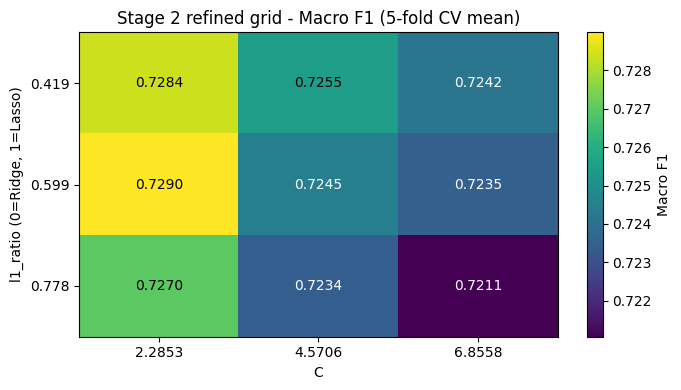

In [7]:
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index="l1_ratio", columns="C", values="mean")

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c:.4f}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{l:.3f}" for l in pivot.index])
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio (0=Ridge, 1=Lasso)")
ax.set_title("Stage 2 refined grid - Macro F1 (5-fold CV mean)")

vmin, vmax = np.nanmin(pivot.values), np.nanmax(pivot.values)
mid = (vmin + vmax) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                color="white" if val < mid else "black")

fig.colorbar(im, ax=ax, label="Macro F1")
plt.tight_layout()
plt.savefig(FIGURES / "logreg_elasticnet_stage2_grid_heatmap.png", dpi=120)
plt.show()

## 6. Persist winning params + fitted model

Only the overall winner gets refit and pickled here - not something every teammate
produces, since pickled sklearn objects are version-sensitive across machines.

In [8]:
stage2_trials = tuning.load_trials("logreg_elasticnet_stage2")

# Select from the COMBINED pool of every trial run, not just stage 2 in isolation -
# same fix applied in 05_tuning.ipynb after a coarser refined grid there failed to beat
# the stage-1 winner; picking from stage 2 alone risks the same silent regression.
all_trials = pd.concat([stage1_trials, stage2_trials], ignore_index=True).sort_values(
    "mean", ascending=False
)
overall_best = all_trials.iloc[0]
best_params = overall_best["params"]
print(f"Best trial across stage 1 ({len(stage1_trials)}) + stage 2 ({len(stage2_trials)}) "
      f"= {len(all_trials)} total trials")
print("Winning params:", best_params)
print(f"Winning Macro F1 (5-fold CV mean): {overall_best['mean']:.4f} (std {overall_best['std']:.4f})")

paths.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
with open(paths.DATA_PROCESSED / "best_logreg_elasticnet_params.json", "w") as f:
    json.dump(best_params, f, indent=2)

final_est = LogisticRegression(
    penalty="elasticnet", solver="saga", max_iter=2000,
    class_weight="balanced", random_state=42, **best_params,
)
final_est.fit(X_dev, y_dev)

paths.MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump(final_est, paths.MODELS / "best_logreg_elasticnet_tuned.pkl")

metadata = {
    "model": "logreg_elasticnet",
    "params": best_params,
    "cv_mean_f1": overall_best["mean"],
    "cv_std_f1": overall_best["std"],
    "n_stage1_trials": len(stage1_trials),
    "n_stage2_trials": len(stage2_trials),
}
with open(paths.MODELS / "best_logreg_elasticnet_tuned.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved best_logreg_elasticnet_params.json, best_logreg_elasticnet_tuned.pkl, "
      "best_logreg_elasticnet_tuned.json")

Best trial across stage 1 (10) + stage 2 (9) = 19 total trials
Winning params: {'C': 2.285282, 'l1_ratio': 0.598658}
Winning Macro F1 (5-fold CV mean): 0.7290 (std 0.0049)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Saved best_logreg_elasticnet_params.json, best_logreg_elasticnet_tuned.pkl, best_logreg_elasticnet_tuned.json


## Discussion / carry-forward -> `06c_holdout_logreg_elasticnet.ipynb`

**Result: C=2.285, l1_ratio=0.599, Macro F1 0.7290** (std 0.0049) across 19 total
trials (10 stage-1 + 9 stage-2). Up from the 04_models baseline (0.7196, arbitrary
`l1_ratio=0.5`) by +0.0094, and edging out tuned Ridge (0.7279) by +0.0011.

**The a priori hypothesis in section 2 was wrong, worth correcting rather than leaving
uncorrected.** That section predicted a low `l1_ratio` (closer to Ridge/L2) would win,
reasoning that the EDA's diffuse-signal finding meant L1 sparsity would discard real
weak signal. The winning `l1_ratio` landed at 0.599 - meaningfully toward Lasso, not
away from it. A plausible revised explanation: some fraction of the 5000 TF-IDF
features may carry little to no genuine signal (noise or near-constant features from
the sparsity check in 01_eda), and a moderate L1 component can prune those specifically
without touching the many weakly-informative-but-real features the diffuse-signal
finding was actually about - "diffuse signal" doesn't mean "every feature matters,"
just that no single feature dominates.

**Performance note:** `solver="saga"` (required for the elasticnet penalty) is
dramatically slower than Ridge's `lbfgs` - roughly 4 minutes per 5-fold CV trial here,
versus seconds for Ridge. No convergence warnings were raised (checked directly), so
this is a genuine speed cost of the elasticnet penalty on 5000 sparse features, not a
correctness issue.

**Filled in after `06c` ran:** holdout Macro F1 0.7395 at the default threshold
(negative gap versus CV, -0.0105 - the same good-surprise direction seen for Ridge, not
overfitting). Threshold tuning found 0.460 as CV-optimal but it actually *hurt* holdout
(-0.0016) - the weakest/most negative local threshold-tuning signal of the three models
tuned so far (LightGBM +0.0031, Ridge +0.0065, this one -0.0016). Both a
default-threshold and a tuned-threshold submission candidate were generated; per the
established pattern (Ridge's tuned threshold underperformed its default on Kaggle:
0.68681 -> 0.67105), the default-threshold candidate was recommended and submitted.

**Real Kaggle result: 0.69576 Macro F1 at the default threshold - the new best score
across every model tried so far**, beating Ridge's 0.68681. The tuned-threshold
candidate (`logreg_elasticnet_task3_tuned_threshold.csv`) is built and ready but not
yet uploaded (Kaggle's one-submission-per-day limit); pending upload will give a second
same-model data point on whether CV-tuned thresholds ever help here, alongside Ridge's
single negative result. See the `project-task3-progress` and
`project-threshold-tuning-finding` memory notes for the full cross-model comparison.